# Least squares

We start by using the least squares for interpolation and fitting by polynomial as an example.

In [8]:
%config InlineBackend.figure_format = 'svg'
import numpy as np
import matplotlib.pyplot as plt

Generate some data:

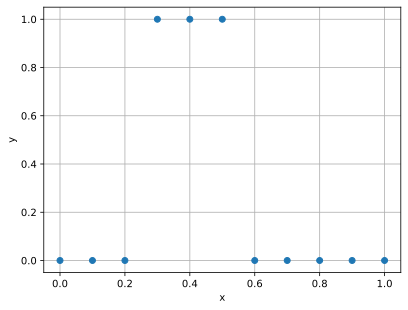

In [9]:
m = 11
x = np.linspace(0.0, 1.0, m)
y = (np.abs(x-0.4) < 0.2)*1.0 + 0.0
plt.plot(x,y,'o')
plt.xlabel("x"); plt.ylabel("y"); plt.grid(True);

## Polynomial interpolation

We solve the matrix problem using numpy.linalg.solve:

In [10]:
A = np.empty((m,m))
for i in range(m):
    A[i,:] = x[i]**np.arange(0,m)
cint = np.linalg.solve(A,y)

The following function evaluates the polynomial with coefficients in the array `c`.

In [11]:
# c = polynomial coefficients, m = len(c)
# Computes degree m-1 polynomial
#    y = sum(i=0,m-1) c[i] * x**i
def p(c,x):
    m = len(c)
    y = 0*x
    for i in range(m):
        y += c[i] * x**i
    return y

Plot the polynomial on a finer set of points:

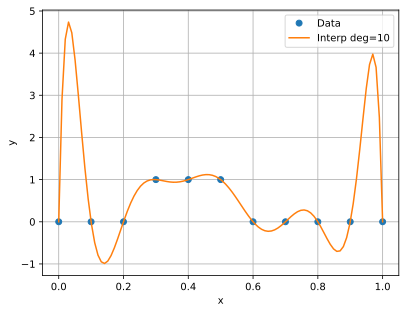

In [12]:
xc = np.linspace(0.0, 1.0, 100)
plt.plot(x,y,'o',label='Data')
plt.plot(xc,p(cint,xc),label='Interp deg='+str(m-1))
plt.xlabel("x"); plt.ylabel("y")
plt.legend()
plt.grid(True)

## Polynomial least squares fit

We solve the least squares problem using numpy.linalg.lstsq:

In [13]:
n7 = 8
A = np.empty((m,n7))
for i in range(m):
    A[i,:] = x[i]**np.arange(0,n7)
cls7,res7,rank7,s7 = np.linalg.lstsq(A,y,rcond=None)

n1 = 2
A = np.empty((m,n1))
for i in range(m):
    A[i,:] = x[i]**np.arange(0,n1)
cls2,res2,rank2,s2 = np.linalg.lstsq(A,y,rcond=None)

n9 = 10
A = np.empty((m,n9))
for i in range(m):
    A[i,:] = x[i]**np.arange(0,n9)
cls9,res9,rank9,s9 = np.linalg.lstsq(A,y,rcond=None)

Plot the interpolating and least squares polynomials:

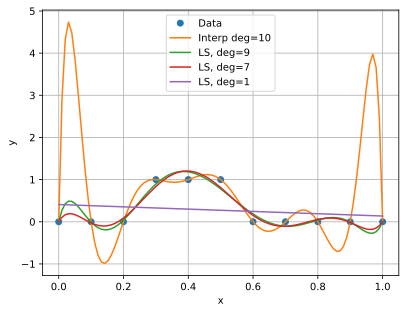

In [14]:
plt.plot(x,y,'o',label='Data')
plt.plot(xc,p(cint,xc),label='Interp deg='+str(m-1))
plt.plot(xc,p(cls9,xc),label='LS, deg='+str(n9-1))
plt.plot(xc,p(cls7,xc),label='LS, deg='+str(n7-1))
plt.plot(xc,p(cls2,xc),label='LS, deg='+str(n1-1))
plt.xlabel("x"); plt.ylabel("y")
plt.legend()
plt.grid(True)

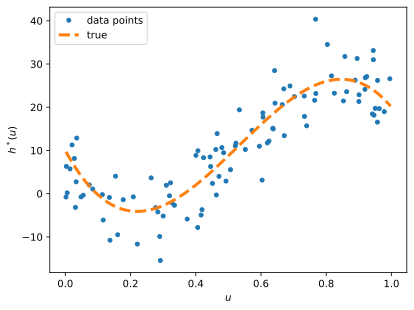

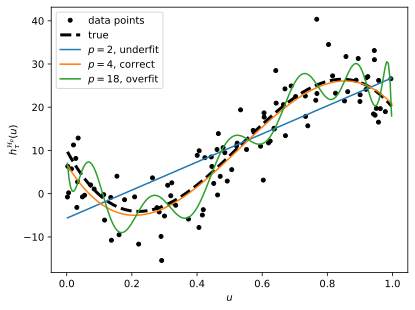

In [15]:
import numpy as np
from numpy.random import rand , randn
from numpy.linalg import norm , solve
import matplotlib.pyplot as plt

def generate_data(beta , sig, n):
  u = np.random.rand(n, 1)
  y = (u ** np.arange(0, 4)) @ beta + sig * np.random.randn(n, 1)
  return u, y

np.random.seed(12)
beta = np.array([[10, -140, 400, -250]]).T
n = 100
sig = 5
u, y = generate_data(beta , sig, n)
xx = np.arange(np.min(u), np.max(u)+5e-3, 5e-3)
yy = np.polyval(np.flip(beta), xx)
plt.plot(u, y, '.', markersize=8)
plt.plot(xx, yy, '--',linewidth=3)
plt.xlabel(r'$u$')
plt.ylabel(r'$h^*(u)$')
plt.legend(['data points','true'])
plt.show()


max_p = 18
p_range = np.arange(1, max_p + 1, 1)
X = np.ones((n, 1))
betahat , trainloss = {}, {}

for p in p_range: # p is the number of parameters
  if p > 1:
    X = np.hstack((X, u**(p-1))) # add column to matrix

  betahat[p] = solve(X.T @ X, X.T @ y)
  trainloss[p] = (norm(y - X @ betahat[p])**2/n)

p = [2, 4, 18] # select three curves
#replot the points and true line and store in the list "plots"
plots = [plt.plot(u, y, 'k.', markersize=8)[0], plt.plot(xx, yy, 'k--',linewidth=3)[0]]
# add the three curves
for i in p:
  yy = np.polyval(np.flip(betahat[i]), xx)
  plots.append(plt.plot(xx, yy)[0])

plt.xlabel(r'$u$')
plt.ylabel(r'$h^{\mathcal{H}_p}_{\tau}(u)$')
plt.legend(plots,('data points', 'true','$p=2$, underfit', '$p=4$, correct','$p=18$, overfit'))
plt.savefig('polyfitpy.pdf',format='pdf')
plt.show()

Text(0, 0.5, 'Test loss')

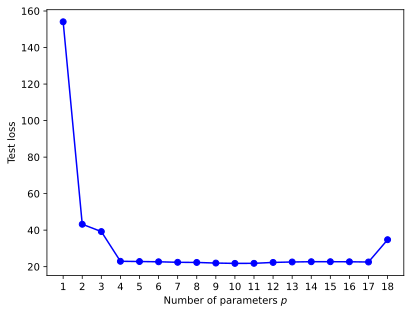

In [16]:
# generate test data
u_test, y_test = generate_data(beta, sig, n)

MSE = []
X_test = np.ones((n, 1))

for p in p_range:
  if p > 1:
    X_test = np.hstack((X_test, u_test**(p-1)))

  y_hat = X_test @ betahat[p] # predictions
  MSE.append(np.sum((y_test - y_hat)**2/n))

plt.plot(p_range, MSE, 'b', p_range, MSE, 'bo')
plt.xticks(ticks=p_range)
plt.xlabel('Number of parameters $p$')
plt.ylabel('Test loss')

## Fitting a straight line

We have some data $(x_i, y_i)$ and we expect a linear relationship between $x$ and $y$

$$
y = c_0 + c_1 x
$$

But the data $y_i$ possibly has some noise.

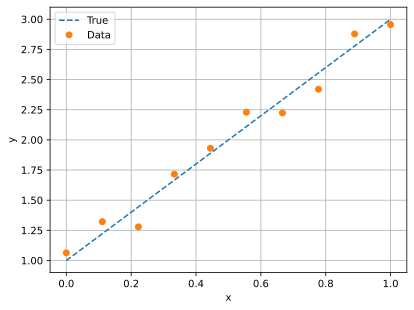

In [17]:
c0 = 1.0
c1 = 2.0

m = 10
x = np.linspace(0.0, 1.0, m)
yt = c0 + c1 * x
plt.plot(x, yt, '--',label='True')
y = yt + 0.2 * (2 * np.random.rand(m) - 1)
plt.plot(x, y, 'o',label='Data')
plt.legend(); plt.grid(True)
plt.xlabel("x"); plt.ylabel("y");

Let us estimate $c_0, c_1$ using least squares fitting.

In [18]:
n = 2
A = np.empty((m,n))
A[:,0] = 1.0
A[:,1] = x
c,res,rank,s = np.linalg.lstsq(A,y,rcond=None)
print('c0 = ', c[0])
print('c1 = ', c[1])

c0 =  1.0346190182272508
c1 =  1.9337582377559506


Plot the fitted line and compare with data and true function.

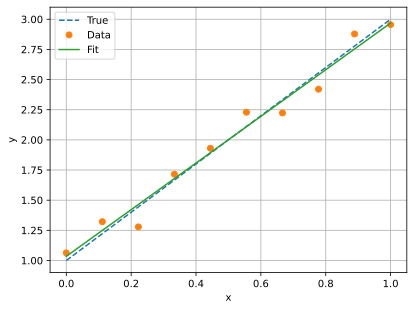

In [19]:
yf = c[0] + c[1] * x
plt.plot(x, yt, '--', label='True')
plt.plot(x, y, 'o',label='Data')
plt.plot(x, yf, '-', label='Fit')
plt.legend(); plt.grid(True)
plt.xlabel("x"); plt.ylabel("y");

## Introduction

Our linear model is:

$$y_i = \beta_0 + \beta_1 x_i + \varepsilon_i$$


We then compute $\beta_0$ , $\beta_1$ using best fit line:

$$\hat{y} = \hat{\beta_0} + \hat{\beta_1}x$$

where $\hat{y}$ is the predicted value and $\beta_0$ , $\beta_1$ are the fitted coefficients.

## Computing Best Fit Line

$$\min_{\beta_0 , \beta_1} \sum_{i=1}^n (y_i - \hat{y_i})^2$$

$$\textrm{(residual) } e_i = y_i - \hat{y_i}$$

Notice $\sum_{i=1}^n (y_i - \hat{y_i})^2 = \sum_{i=1}^n e_i^2$.


Let's consider the the data: $(x_{1},y_{1}),(x_{2},y_{2}),\ldots,(x_{n},y_{n})$ and we want to minimize
\begin{equation*}
E=\sum_{i=1}^{n}(y_{i}-ax_{i}-b)^{2}
\end{equation*}
with respect to the parameters $a,b.$ For a minimum to occur, we
must have
\begin{equation*}
\frac{\partial E}{\partial a}=0\text{ and }\frac{\partial E}{\partial b}=0.
\end{equation*}
We therefor have:
\begin{align*}
\frac{\partial E}{\partial a} & =\sum_{i=1}^{n}\frac{\partial (y_{i}-ax_{i}-b)^{2}}{\partial a}=\sum_{i=1}^{n}(-2x_{i})(y_{i}-ax_{i}-b)=0\\
\frac{\partial E}{\partial b} & =\sum_{i=1}^{n}\frac{\partial (y_{i}-ax_{i}-b)^{2}}{\partial b}=\sum_{i=1}^{n}(-2)(y_{i}-ax_{i}-b)=0.
\end{align*}
which gives
\begin{align*}
b\sum_{i=1}^{n}x_{i}+a\sum_{i=1}^{n}x_{i}^{2} & =\sum_{i=1}^{n}x_{i}y_{i}\\
bn+a\sum_{i=1}^{n}x_{i} & =\sum_{i=1}^{n}y_{i},
\end{align*}
which are called the **normal equations**. The solution to this system
of equations is
\begin{align*}
a  =\frac{n\sum_{i=1}^{n}x_{i}y_{i}-\sum_{i=1}^{n}x_{i}\sum_{i=1}^{n}y_{i}}{n\left(\sum_{i=1}^{n}x_{i}^{2}\right)-\left(\sum_{i=1}^{n}x_{i}\right)^{2}},
b  =\frac{\sum_{i=1}^{n}x_{i}^{2}\sum_{i=1}^{n}y_{i}-\sum_{i=1}^{n}x_{i}y_{i}\sum_{i=1}^{n}x_{i}}{n\left(\sum_{i=1}^{n}x_{i}^{2}\right)-\left(\sum_{i=1}^{n}x_{i}\right)^{2}}.
\end{align*}



In [20]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

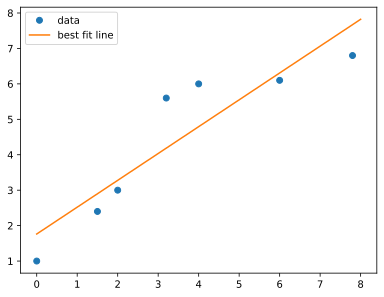

In [21]:
# create data
xdata = [0,1.5,2,3.2,4,6,7.8]
ydata = [1,2.4,3,5.6,6,6.1,6.8]

# use scipy.stats.linregress to calculate a line of best fit and extract the key info
slope, intercept, r, p, se = stats.linregress(xdata,ydata)

# create a lambda function to plot the line of best fit
xline = np.linspace(0,8,10)
y = lambda x: slope*x + intercept
yline = y(xline)

# plot data
plt.plot(xdata,ydata,'o',label="data")
plt.plot(xline,yline,'-',label="best fit line")
plt.legend()
plt.show()

## Measuring Goodness-of-Fit


$$r^2 = \frac{\sum_{i=1}^n (y_i - \bar{y})^2 - \sum_{i=1}^n (y_i - \hat{y_i})^2}{\sum_{i=1}^n (y_i - \bar{y})^2}$$



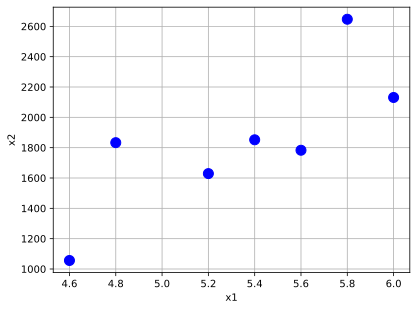

In [22]:
x1 = np.array([4.6, 4.8, 5.2, 5.4, 5.6, 5.8, 6.0])
x2 = np.array([1056, 1833, 1629, 1852, 1783, 2647, 2131])

plt.plot(x1,x2,'b.',markersize=20)
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)
plt.show()

In [23]:
x = x1
y = x2
n = len(x)

# calculate averages
xbar = np.mean(x)
ybar = np.mean(y)

# calculate numerator
# num = # fill in
num = (x - xbar).dot(y - ybar)

# calculate denominator
# denom = # fill in
denom = (x - xbar).dot(x-xbar)

# calculate slope
b1 = num / denom

# calculate intercept
b0 = ybar - b1 * xbar

# print results
print("slope = ",b1)
print("intercept =",b0)

slope =  737.1014492753623
intercept = -2090.9420289855075


Using Scipy:

In [24]:
b1_, b0_, y_value, x_value, std_err = stats.linregress(x, y)

print("slope = ",b1_)
print("intercept =",b0_)

slope =  737.1014492753623
intercept = -2090.9420289855075


## Visualize

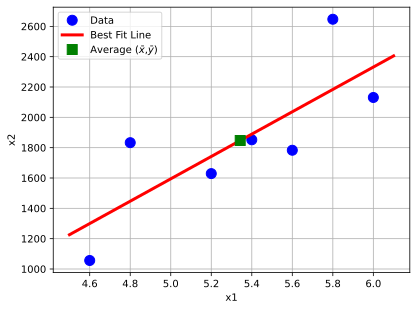

In [25]:
# generate predictions
x1_pred = np.linspace(4.5, 6.1, 20)
x2_pred = b0_ + b1_ * x1_pred

# create plot
plt.plot(x1,x2,'.b',markersize=20,label='Data')
plt.plot(x1_pred,x2_pred,'-r',linewidth=3,label='Best Fit Line')
plt.plot(xbar,ybar,'sg',markersize=10,label=r"Average ($\bar{x}$,$\bar{y}$)")
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)
plt.legend()
plt.show()

## Normal equations

Systems with more equations than unknowns are called overdetermined.
If $A$ is an $m \times n$ matrix, then in general, an $m \times 1$ vector $b$ may not lie in the column space of $A$. Hence $Ax = b$ may not have an exact solution. The least squares solution is given by minimizing the square of the residual

$$
{\bf r} = {\bf y} - A {\bf x}
$$

in the 2-norm. Therefore
$$
\phi(x) = ||{\bf r}||^2_2 = {\bf r}^T{\bf r}=({\bf y} - A {\bf x})^T({\bf y} - A {\bf x}) = {\bf y}^T{\bf y} - 2{\bf x}^TA^T {\bf y} + {\bf x}^TA^TA {\bf x}
$$

We know that the minimizer occurs where $\nabla \phi(x) = 0$:

$$
\nabla \phi(x) = -2A^T{\bf y} + 2A^TA{\bf x} = 0
$$

The system of normal equations is therefor given by:

$$
A^T{\bf y} = A^TA{\bf x}
$$

The normal equations has a unique solution if $rank(A) = n$.

## Normal equations, a Geometric View

If the vector ${\bf y}$ is not in the span (the set of all linear combinations of vectors) of the columns of $A$ then in order to find the minimum distance from ${\bf y}$ to the span of the columns of $A$, we need to find $\hat{\bf x}$ such that ${\bf r} = {\bf y} - A \hat{\bf x}$ is orthogonal to $A{\bf x}$ for any ${\bf x}$.

![](https://drive.google.com/uc?export=view&id=1hPag-pI9TuGihER-_S3K-CuudVjgtT4h)    



## Normal equations: conditioning

The normal equations tend to worsen the condition of the matrix. For $A_{m \times n}$:

$$
cond(A) = ||A||_2||A^+||_2
$$

and it can be shown that

$$
cond(AA^T) = (cond(A))^2
$$

## Other approaches

The SVD of $A$ leads to its pseudoinverse $A^+$. Then $\hat{\bf x}= A^+ {\bf y}$.

The Gram-Schmidt process produces orthogonal columns in $Q$. Then $A = QR$.


In [26]:
import numpy as np
import numpy.linalg as npl
import scipy.linalg as spl
import math
import matplotlib.pyplot as plt
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Least Squares Problem

In [27]:
A,b = np.matrix([[2,0],[-1,1],[0,2]]), np.array([1,0,-1])
xhat = np.array([1/3,-1/3])
rhat = np.matmul(A,xhat) - b
npl.norm(rhat)
x = np.array([1/2,-1/2])
r = np.matmul(A,x) - b
npl.norm(r)
rhat

np.float64(0.816496580927726)

np.float64(1.0)

matrix([[-0.33333333, -0.66666667,  0.33333333]])

In [28]:
np.matmul(npl.inv(A.transpose()*A)*A.transpose(),b)
np.matmul(npl.pinv(A),b)
np.matmul(np.matmul(A.transpose(),A),xhat) - np.matmul(A.transpose(),b)

matrix([[ 0.33333333, -0.33333333]])

matrix([[ 0.33333333, -0.33333333]])

matrix([[0.00000000e+00, 2.22044605e-16]])

In [29]:
z = np.array([-1.1,2.3])
# np.shape(np.matmul(A,z))
# np.shape(rhat)
np.matmul(A,z) @ rhat.transpose()

matrix([[2.22044605e-16]])

# Solving Least Squares Problems

In [30]:
A,b = np.random.randn(100,20),np.random.randn(100)

In [31]:
x1 = npl.lstsq(A,b)[0] #lstsq gives the solution, residuals and rank, need to choose [0]
x2 = np.matmul(npl.inv(np.matmul(A.transpose(),A)),np.matmul(A.transpose(),b))
x3 = np.matmul(npl.pinv(A),b)
Q,R = npl.qr(A)
x4 = npl.solve(R,(np.matmul(Q.transpose(),b)))

npl.norm(x1-x2)
npl.norm(x2-x3)
npl.norm(x3-x4)

np.float64(7.371921671606436e-16)

np.float64(7.335316729871563e-16)

np.float64(6.417750111486898e-16)

In [32]:
np.shape(A)

(100, 20)

In [33]:
x1

array([ 0.16535349,  0.2718652 ,  0.07511873, -0.1290572 , -0.07319192,
        0.04347333,  0.05794386,  0.04376511,  0.14793752,  0.20295588,
        0.14661688, -0.11155472, -0.0177661 ,  0.03320135, -0.01544897,
        0.03061661,  0.11740045, -0.12029878,  0.20396729,  0.03040473])

#### Complexity:
1. doubling m doubles compute time
2. doubling n quadruples compute time

In [34]:
m,n = 2000, 500
A,b = np.random.randn(m,n), np.random.randn(m)
%timeit npl.lstsq(A,b)

202 ms ± 70.5 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [35]:
m,n = 4000, 500
A,b = np.random.randn(m,n), np.random.randn(m)
%timeit npl.lstsq(A,b)

The slowest run took 6.90 times longer than the fastest. This could mean that an intermediate result is being cached.
613 ms ± 453 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [36]:
m,n = 2000, 1000
A,b = np.random.randn(m,n), np.random.randn(m)
%timeit npl.lstsq(A,b)

778 ms ± 25.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [37]:
A,B = np.random.randn(1000,100), np.random.randn(1000,10)
X = npl.lstsq(A,B)[0]
x3 = npl.lstsq(A,B[:,3])[0]
npl.norm(X[:,3]-x3)

np.float64(3.0397038295654183e-16)